<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
모델 저장·복원·단일 추론
</div>

# 데이터 로드와 시각화

**목표**: FashionMNIST 학습·테스트 셋을 메모리에 올리고, 학습자가 첫 샘플 한 장의 모양과 클래스 분포를 눈으로 확인합니다.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_ds = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_ds = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())
print("train size:", len(train_ds), "  test size:", len(test_ds))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.3MB/s]

train size: 60000   test size: 10000


In [3]:
x0, y0 = train_ds[0]
print("x0.shape:", x0.shape, "  x0.dtype:", x0.dtype, "  y0:", y0)

x0.shape: torch.Size([1, 28, 28])   x0.dtype: torch.float32   y0: 9


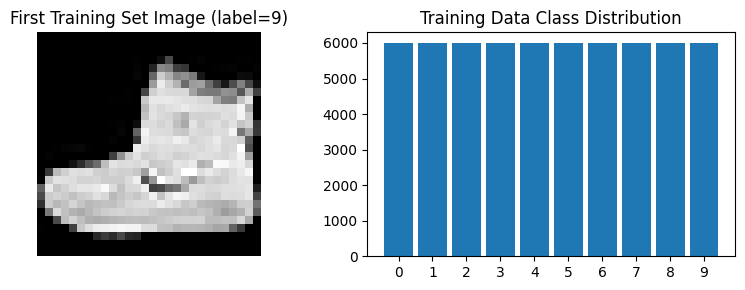

In [4]:
# 데이터 시각화: 첫 샘플 이미지 한 장 + 학습셋의 클래스 분포
labels = np.array([y for _, y in train_ds])
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(x0.squeeze(), cmap="gray")
axes[0].set_title(f"First Training Set Image (label={y0})")
axes[0].axis("off")
axes[1].hist(labels, bins=np.arange(11) - 0.5, rwidth=0.85)
axes[1].set_xticks(range(10))
axes[1].set_title("Training Data Class Distribution")
plt.tight_layout()
plt.show()

# 모델 정의와 1 epoch 학습

**목표**: 28×28 입력을 받는 작은 MLP 를 정의하고, 저장할 가중치를 만들기 위해 1 epoch 만 학습합니다.

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.linear_relu_stack(self.flatten(x))

In [6]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
model = SimpleMLP()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

In [7]:
model.train()                              # 학습 모드 명시
for batch_idx, (x, y) in enumerate(train_loader):
    pred = model(x)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch_idx == 0:
        print(f"첫 배치 loss: {loss.item():.4f}")
print(f"마지막 배치 loss: {loss.item():.4f}")

첫 배치 loss: 2.2480
마지막 배치 loss: 0.8582


# `state_dict` 저장과 키 확인

**목표**: 학습한 가중치를 `state_dict` 한 줄로 파일에 저장하고, 키 이름이 모델 구조 코드를 그대로 반영한다는 사실을 직접 확인합니다.

In [8]:
torch.save(model.state_dict(), "mnist_mlp_weights.pth") #SimpleMLP() 데이터를 저장한다는 코드

In [9]:
state = model.state_dict()
print("키 개수:", len(state))
print("처음 4개 키:")
for k in list(state.keys())[:4]:
    print(" ", k, tuple(state[k].shape))

키 개수: 4
처음 4개 키:
  linear_relu_stack.0.weight (256, 784)
  linear_relu_stack.0.bias (256,)
  linear_relu_stack.2.weight (10, 256)
  linear_relu_stack.2.bias (10,)


# 복원 3줄 레시피 (빈 모델 → `load_state_dict` → `eval`)

**목표**: 같은 프로세스에서도 §4-2 의 3줄 레시피를 그대로 적용해 가중치가 안전하게 주입되는지 확인합니다.

In [10]:
restored = SimpleMLP()                                # (1) 같은 구조의 빈 모델
restored.load_state_dict(                             # (2) 가중치 주입
    torch.load("mnist_mlp_weights.pth", weights_only=True)
)
restored.eval()                                       # (3) 평가 모드

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [11]:
# 살아 있는 model 과 restored 가 같은 가중치를 가졌는지 한 텐서로 검증
same = torch.equal(
    model.state_dict()["linear_relu_stack.0.weight"],
    restored.state_dict()["linear_relu_stack.0.weight"],
)
print("첫 Linear weight 일치 여부:", same)
print("restored.training:", restored.training)

첫 Linear weight 일치 여부: True
restored.training: False


**해석**: 학습 모델과 복원 모델의 가중치가 비트 단위로 같습니다. `restored.training` 이 `False` 인 것은 `eval()` 이 잘 적용됐다는 신호입니다.

# 단일 샘플 추론과 결정성 확인

**목표**: 복원 모델로 테스트셋 첫 샘플 한 장을 분류하고, 같은 입력을 두 번 넣어도 결과가 일치하는지 확인합니다.

In [12]:
x_test, y_test = test_ds[0]
print("입력 shape:", x_test.unsqueeze(0).shape)   # (1, 1, 28, 28)

입력 shape: torch.Size([1, 1, 28, 28])


In [13]:
with torch.inference_mode():
    logits_a = restored(x_test.unsqueeze(0))
    logits_b = restored(x_test.unsqueeze(0))
    pred_a = logits_a.argmax(dim=1).item()
    pred_b = logits_b.argmax(dim=1).item()

print(f"두 번 예측: {pred_a} vs {pred_b}   (정답 {y_test})")
print("두 logits 가 비트 단위로 같은가:", torch.equal(logits_a, logits_b))

두 번 예측: 9 vs 9   (정답 9)
두 logits 가 비트 단위로 같은가: True


# 보조 예제: 전체 객체 저장의 깨짐 재현

**목표**: `torch.save(model, path)` 한 줄로 저장한 파일이 클래스 참조가 사라지는 순간 어떻게 실패하는지 직접 재현합니다.

In [14]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 2)

    def forward(self, x):
        return self.linear(x)

In [15]:
tiny = TinyNet()
torch.save(tiny, "whole_model.pth")              # 전체 객체 저장 (legacy)
print("저장 완료 — 파일에는 클래스 경로까지 박혀 있습니다.")

저장 완료 — 파일에는 클래스 경로까지 박혀 있습니다.


In [16]:
# 1) 같은 스코프에 클래스가 있으면 로드 성공
loaded_ok = torch.load("whole_model.pth", weights_only=False)
print("정상 로드:", type(loaded_ok).__name__)

정상 로드: TinyNet


In [17]:
# 2) 클래스 참조를 제거하면 pickle 이 클래스를 못 찾아 깨집니다
backup = TinyNet
del TinyNet
try:
    _ = torch.load("whole_model.pth", weights_only=False)
except Exception as exc:
    print(f"예상된 실패: {type(exc).__name__}: {exc}")
finally:
    TinyNet = backup      # 복구 (이후 셀에서 다시 쓸 수 있게)

예상된 실패: AttributeError: Can't get attribute 'TinyNet' on <module '__main__'>


# 단독 확인: `map_location` 으로 CPU 에서 안전하게 로드

**목표**: GPU 환경에서 저장된 가중치를 CPU 환경에서 그대로 받아 쓰는 안전한 호출 방식을 익힙니다.

In [18]:
# GPU 가 없어도 'cpu' 로 명시하는 습관을 만들어 둡니다.
state_cpu = torch.load(
    "mnist_mlp_weights.pth",
    weights_only=True,
    map_location="cpu", #RNN에서 CPU 사용 불가능, 데이터 분석이 너무 오래 걸려서
)
restored_cpu = SimpleMLP()
restored_cpu.load_state_dict(state_cpu)
restored_cpu.eval()

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [19]:
# 파라미터 device 확인
first_param = next(restored_cpu.parameters())
print("first param device:", first_param.device)

first param device: cpu


# 단독 확인: 일반 체크포인트 패턴

**목표**: 모델 외 옵티마이저·epoch·loss 까지 한 사전에 묶어 저장·복원하고, `weights_only=True` 가 그대로 안전하게 동작함을 확인합니다.

In [20]:
epoch = 1
best_loss = 0.4321

ckpt = {
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch":                epoch,
    "loss":                 best_loss,
}
torch.save(ckpt, "mnist_mlp_ckpt.pt")

# 복원
ckpt_loaded = torch.load("mnist_mlp_ckpt.pt", weights_only=True)
print("ckpt 키:", list(ckpt_loaded.keys()))

resumed = SimpleMLP()
resumed_optim = torch.optim.SGD(resumed.parameters(), lr=1e-2)
resumed.load_state_dict(ckpt_loaded["model_state_dict"])
resumed_optim.load_state_dict(ckpt_loaded["optimizer_state_dict"])
start_epoch = ckpt_loaded["epoch"] + 1
print("resume start epoch:", start_epoch, "  prev loss:", ckpt_loaded["loss"])

ckpt 키: ['model_state_dict', 'optimizer_state_dict', 'epoch', 'loss']
resume start epoch: 2   prev loss: 0.4321
